In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.stats import pearsonr

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
fCC = tables.open_file('../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../dataset_complete/merger/merged_NC_0.h5', mode='r')

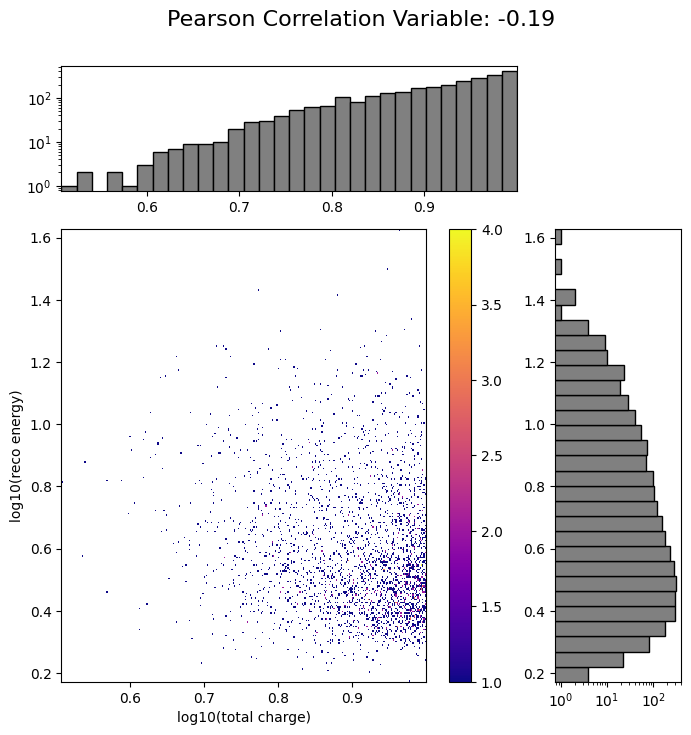

In [3]:
x =  np.log10(fCC.root.TotalCharge.col('value')[fCC.root.TotalCharge.col('value') <= 10])
y =  np.log10(fCC.root.RecoEnergy.col('value')[fCC.root.TotalCharge.col('value') <= 10])

# Create the layout
fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

main_ax = fig.add_subplot(grid[1:4, 0:3])  # Scatter plot
x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)  # Top histogram
y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)  # Right histogram

# Scatter plot (correlation)
hist = main_ax.hist2d(x, y, bins=300, cmap='plasma', cmin=1)
main_ax.set_xlabel("log10(total charge)")
main_ax.set_ylabel("log10(reco energy)")

cbar = plt.colorbar(hist[3], ax=main_ax)
#cbar.set_label("Counts")

# Top histogram (distribution of x)
x_hist.hist(x, bins=30, color="gray", edgecolor='black', log = True)
x_hist.axis('on')

# Right histogram (distribution of y)
y_hist.hist(y, bins=30, orientation='horizontal', color="gray", edgecolor='black', log=True)
y_hist.axis('on')

corr_val, _ = pearsonr(x, y)

fig.suptitle('Pearson Correlation Variable: ' + str(np.round(corr_val, 2)), fontsize=16, y=0.95)

plt.show()

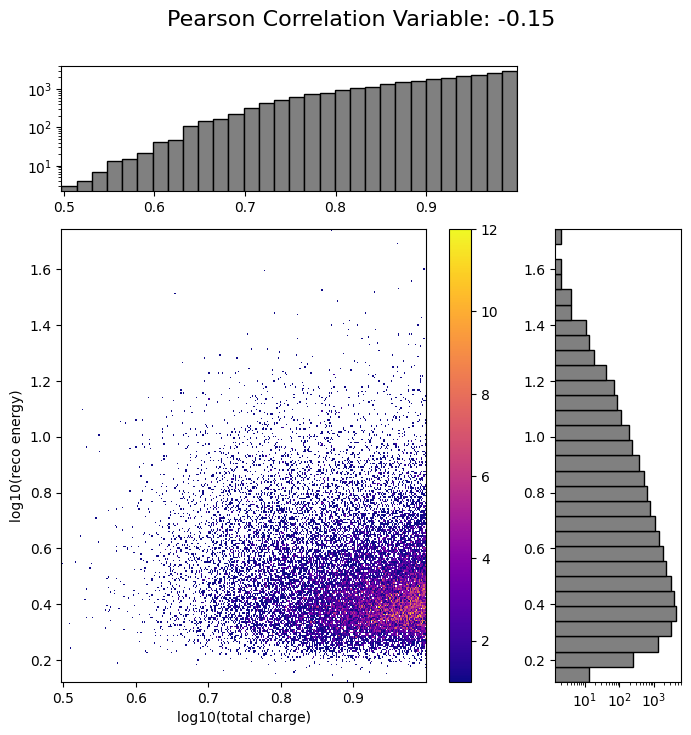

In [4]:
x = np.log10(fNC.root.TotalCharge.col('value')[fNC.root.TotalCharge.col('value') <= 10])
y = np.log10(fNC.root.RecoEnergy.col('value')[fNC.root.TotalCharge.col('value') <= 10])

# Create the layout
fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

main_ax = fig.add_subplot(grid[1:4, 0:3])  # Scatter plot
x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)  # Top histogram
y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)  # Right histogram

# Scatter plot (correlation)
hist = main_ax.hist2d(x, y, bins=300, cmap='plasma', cmin=1)
main_ax.set_xlabel("log10(total charge)")
main_ax.set_ylabel("log10(reco energy)")

cbar = plt.colorbar(hist[3], ax=main_ax)
#cbar.set_label("Counts")

# Top histogram (distribution of x)
x_hist.hist(x, bins=30, color="gray", edgecolor='black', log = True)
x_hist.axis('on')

# Right histogram (distribution of y)
y_hist.hist(y, bins=30, orientation='horizontal', color="gray", edgecolor='black', log=True)
y_hist.axis('on')

corr_val, _ = pearsonr(x, y)

fig.suptitle('Pearson Correlation Variable: ' + str(np.round(corr_val, 2)), fontsize=16, y=0.95)

plt.show()

In [5]:
# Reading columns
event_ids = fCC.root.EventCounter.col('value')
om_counter = fCC.root.OMMapReco.col('om_counter')
angles = fCC.root.OMMapReco.col('angle')
energies = fCC.root.OMMapReco.col('om_renergy')

#coverting to arrays 
event_ids = np.asarray(event_ids) #arrays make is fast but still not as fast as the code below
om_counter = np.asarray(om_counter)
angles = np.asarray(angles)
energies = np.asarray(energies)

angle_summ = []
energy = []
counter = 0
for i in event_ids:
    boolean = (om_counter == i)
    angle = angles[boolean]
    angle_summ.append(np.sum(np.cos(angle)))
    energy.append(energies[boolean][0])

    if counter % 100 == 0:
        print(counter)
    counter+=1

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800


KeyboardInterrupt: 

In [6]:
def get_var_summary(f):

    # Reading columns
    event_ids = f.root.EventCounter.col('value')
    om_counter = f.root.OMMapReco.col('om_counter')
    angles = f.root.OMMapReco.col('time_residual') #f.root.OMMapReco.col('distance')#f.root.OMMapReco.col('angle')
    energies = f.root.OMMapReco.col('om_renergy')
    charges = f.root.OMMapReco.col('om_total_charge')

    #coverting to arrays 
    angles = np.asarray(angles) #np.cos(np.asarray(angles))
    
    min_val = -1
    max_val = 300
       
    bool_ = (angles>=min_val)&(angles<=max_val)
    
    angles = angles[bool_]
    event_ids = np.asarray(event_ids)
    om_counter = np.asarray(om_counter)[bool_]
    #angles = np.asarray(angles)[bool_] #np.cos(np.asarray(angles))
    energies = np.asarray(energies)[bool_]
    charges = np.asarray(charges)[bool_]

    print('len is: ', len(angles), len(om_counter))
    
    angle_summ = []

    # Create a mapping from om_counter to indices
    from collections import defaultdict
    
    index_map = defaultdict(list) #making a default dictionary is truly a game changer it is very fast
    for idx, val in enumerate(om_counter):
        index_map[val].append(idx)
        #print(index_map)
    
    # Iterate once
    for counter, event_id in enumerate(event_ids):
        indices = index_map[event_id]
        angle_vals = angles[indices]
        if len(energies[indices]) != 0:
            energy_val = energies[indices][0]  # first energy for that event
            charge_val = charges[indices][0]
    
            angle_summ.append((np.mean(angle_vals), np.std(angle_vals), np.median(angle_vals), np.sum(angle_vals), 
                               kurtosis(angle_vals), skew(angle_vals), energy_val, charge_val))
        
        if counter % 1000 == 0:
            print(counter)

    return map(np.array, zip(*angle_summ))

In [23]:
meanCC, stdCC, medianCC, sumCC, kurtosisCC, skewCC, energyCC, charge_valCC = get_var_summary(fCC)
meanNC, stdNC, medianNC, sumNC, kurtosisNC, skewNC, energyNC, charge_valNC = get_var_summary(fNC)

len is:  5178884 5178884
0


/tmp/ipykernel_4974/3767176597.py:46: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(angle_vals), skew(angle_vals), energy_val, charge_val))


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
len is:  9263860 9263860
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000

In [24]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):

    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [ ]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 2 #np.log10(100)
    else:
        max_val = 2.5 #np.log10(100) #charge

    steps = np.arange(0, max_val, 0.1)

    #print(steps)

    diff_varCC = np.log10(diff_varCC)
    diff_varNC = np.log10(diff_varNC)
        
    for i in steps:#range(0, len(charge_val)-1):#
        
        qmin= i #charge_val[i]#
        qmax= i+0.1 #charge_val[i+1]#

        #print(qmin, qmax)
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len(xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-(0.1/2)) #append(qmax - 5)

            plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            plt.title(np.round(ks_statistic, 3))
            plt.show()

    return sep_var, p_val, bin_centers

In [25]:
meanCC, stdCC, medianCC, sumCC, kurtosisCC, skewCC, energyCC, charge_valCC


sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(meanCC, meanNC, energyCC, energyNC)
sep_var_std, p_val_std, bin_centers_std = get_statistic(stdCC, stdNC, energyCC, energyNC)
sep_var_median, p_val_median, bin_centers_median = get_statistic(medianCC, medianNC, energyCC, energyNC)
sep_var_sum, p_val_sum, bin_centers_sum = get_statistic(sumCC, sumNC, energyCC, energyNC)
sep_var_kurtosis, p_val_kurtosis, bin_centers_kurtosis = get_statistic(kurtosisCC, kurtosisNC, energyCC, energyNC)
sep_var_skew, p_val_skew, bin_centers_skew = get_statistic(skewCC, skewNC, energyCC, energyNC)

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

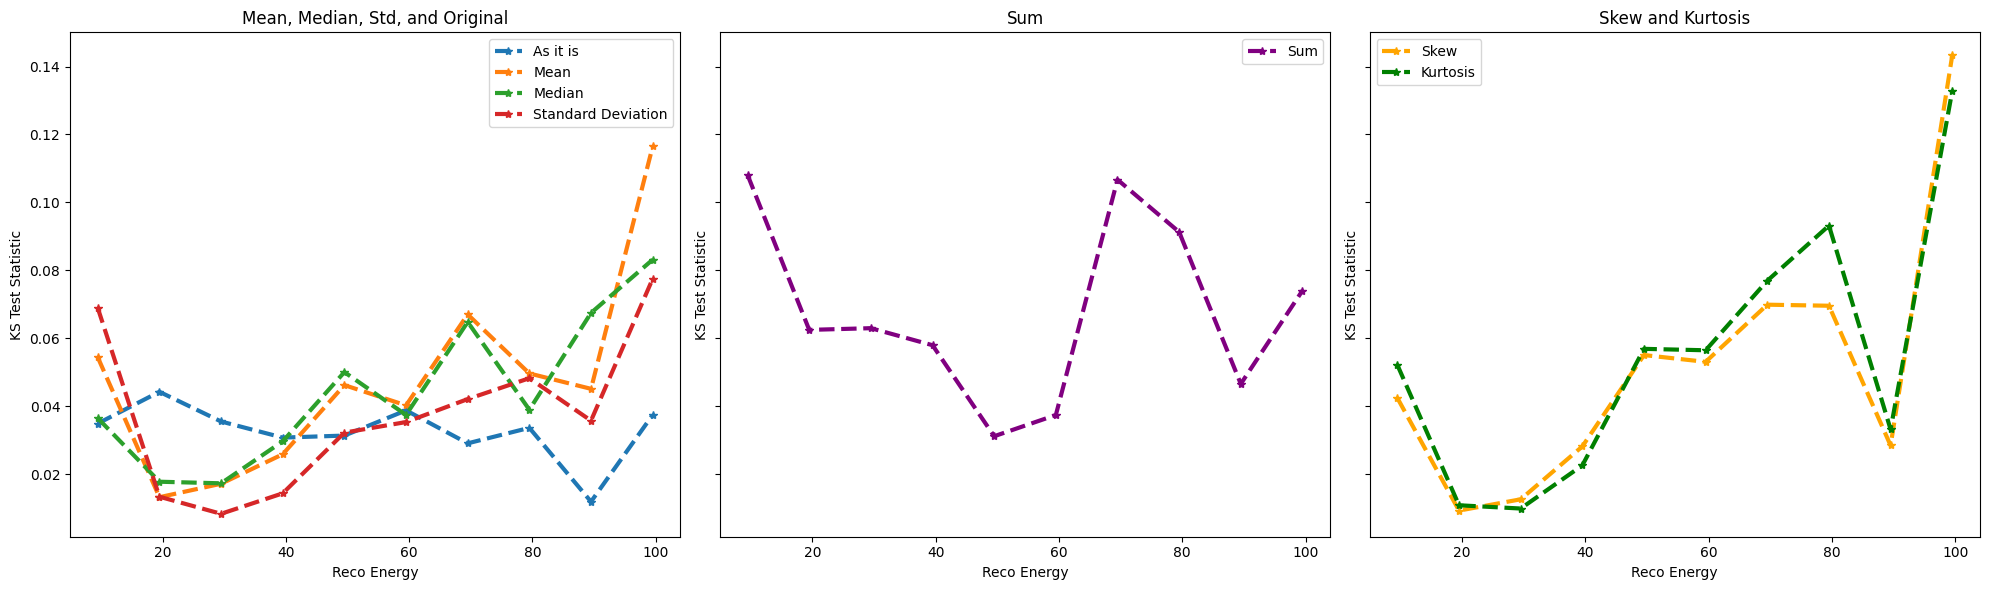

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(bin_centers_mean, sep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(bin_centers_median, sep_var_median, '*--', linewidth=3, label='Median')
axs[0].plot(bin_centers_std, sep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Reco Energy')
axs[0].legend()
axs[0].set_title("Mean, Median, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(bin_centers_sum, sep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].set_title("Sum")

# --- Subplot 3 ---
axs[2].plot(bin_centers_skew, sep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(bin_centers_kurtosis, sep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Reco Energy')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

In [27]:
csep_var_mean, cp_val_mean, cbin_centers_mean = get_statistic(meanCC, meanNC, charge_valCC, charge_valNC, energy=False)
csep_var_std, cp_val_std, cbin_centers_std = get_statistic(stdCC, stdNC, charge_valCC, charge_valNC, energy=False)
csep_var_median, cp_val_median, cbin_centers_median = get_statistic(medianCC, medianNC, charge_valCC, charge_valNC, energy=False)
csep_var_sum, cp_val_sum, cbin_centers_sum = get_statistic(sumCC, sumNC, charge_valCC, charge_valNC, energy=False)
csep_var_kurtosis, cp_val_kurtosis, cbin_centers_kurtosis = get_statistic(kurtosisCC, kurtosisNC, charge_valCC, charge_valNC, energy=False)
csep_var_skew, cp_val_skew, cbin_centers_skew = get_statistic(skewCC, skewNC, charge_valCC, charge_valNC, energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

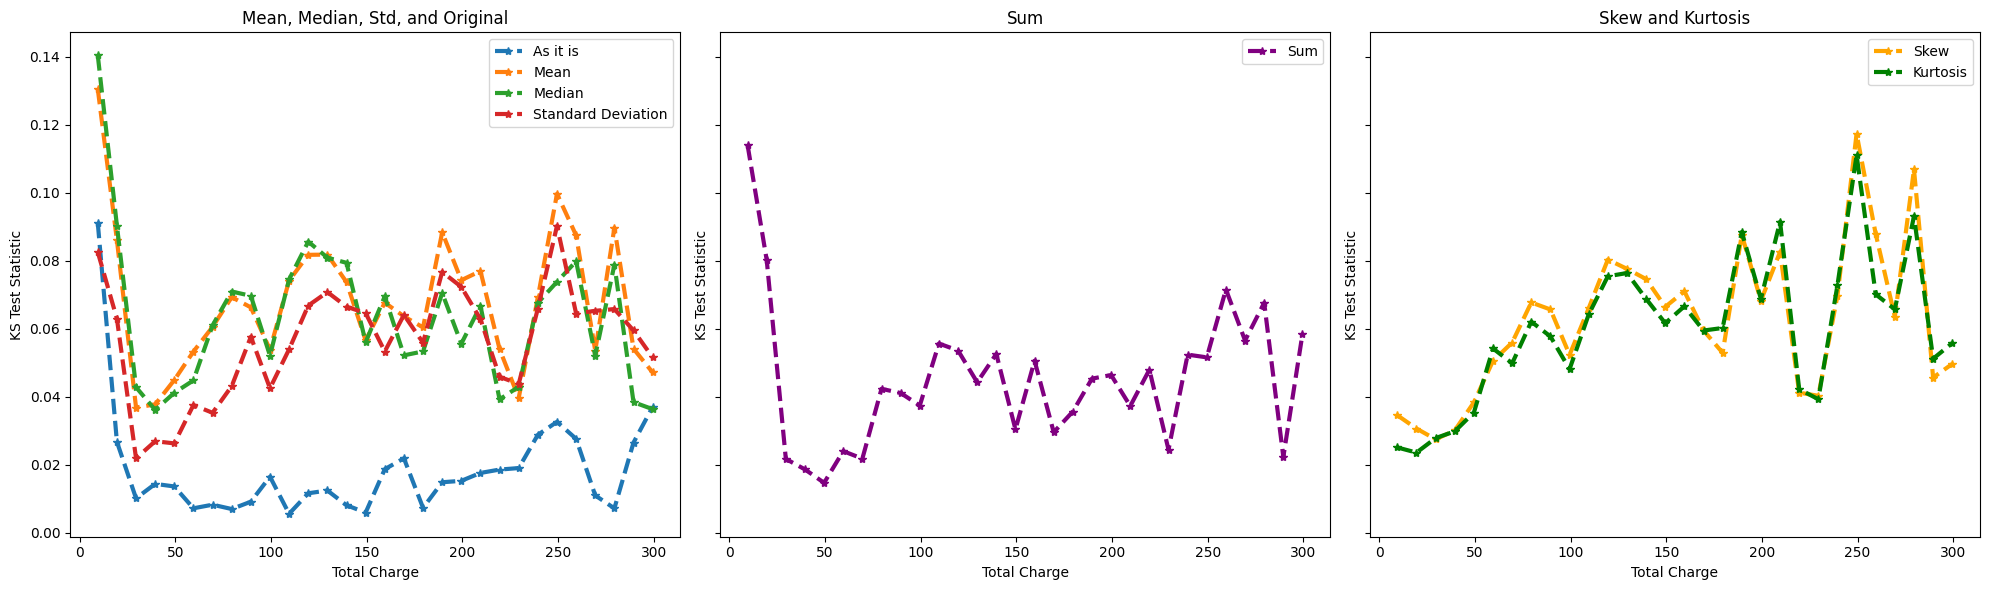

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(cbin_centers_mean, csep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(cbin_centers_median, csep_var_median, '*--', linewidth=3, label='Median')
axs[0].plot(cbin_centers_std, csep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Total Charge')
axs[0].legend()
axs[0].set_title("Mean, Median, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(cbin_centers_sum, csep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].set_title("Sum")

# --- Subplot 3 ---
axs[2].plot(cbin_centers_skew, csep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(cbin_centers_kurtosis, csep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Total Charge')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

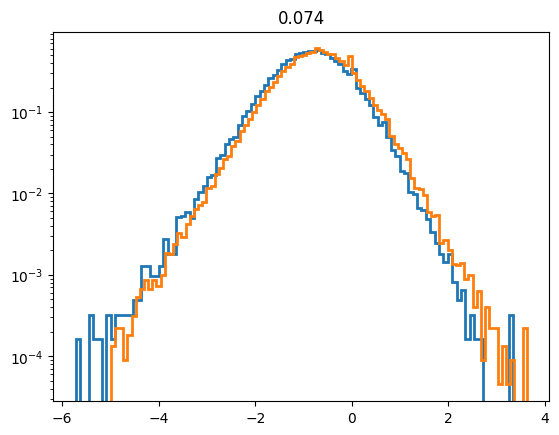

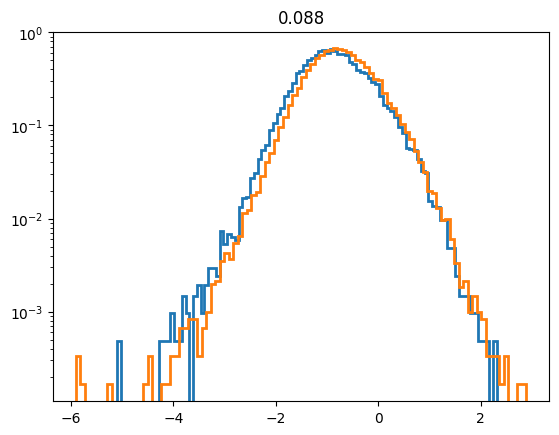

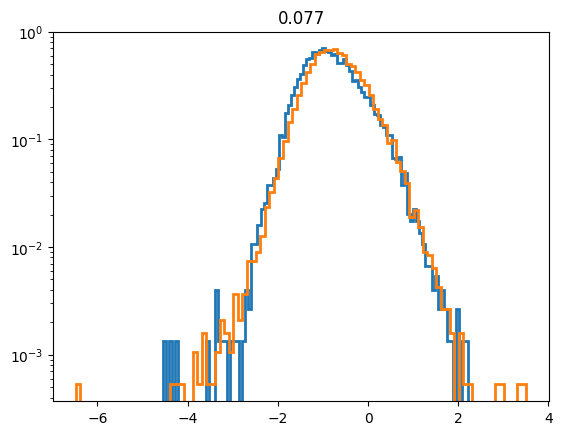

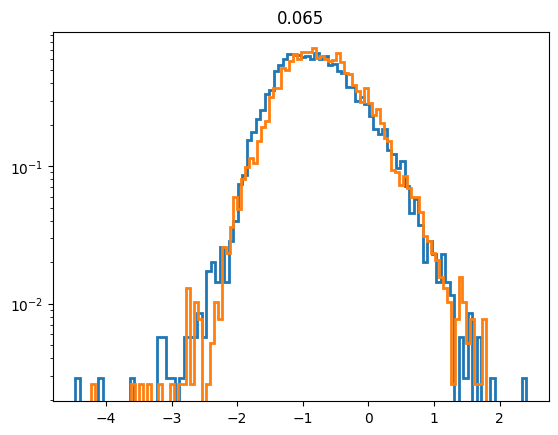

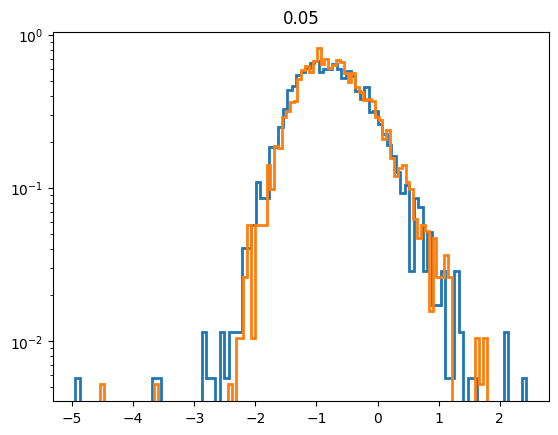

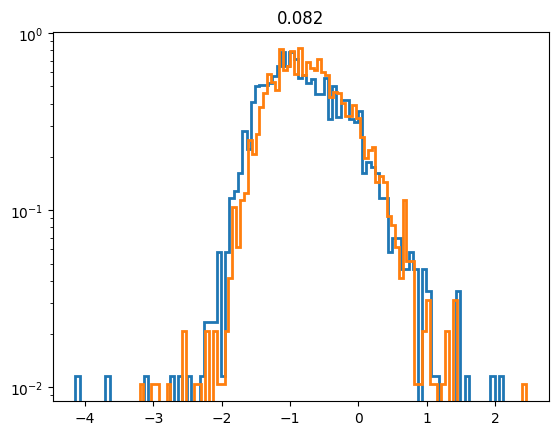

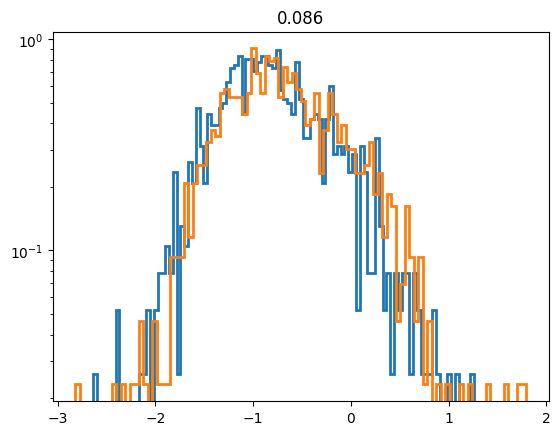

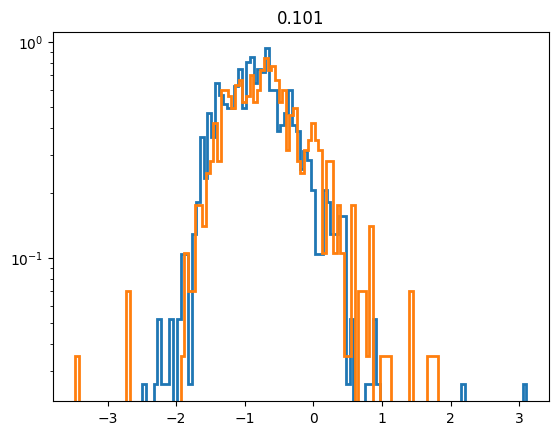

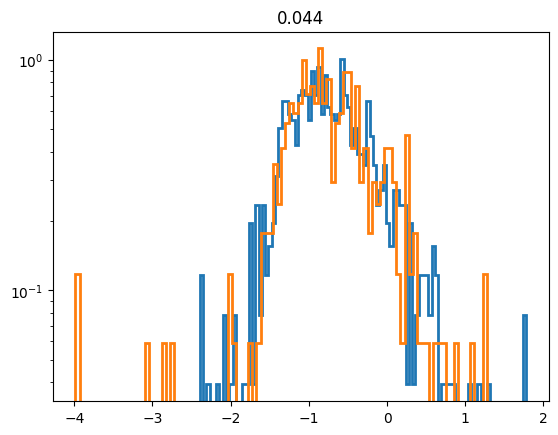

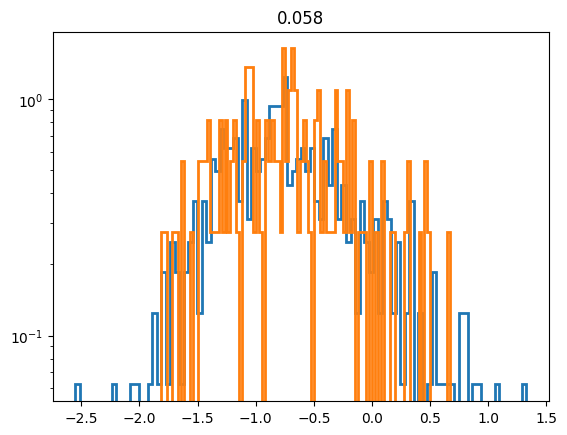

In [58]:
sep_var, p_val, bin_centers = get_statistic(angle_summCC, angle_summNC, energyCC, energyNC)

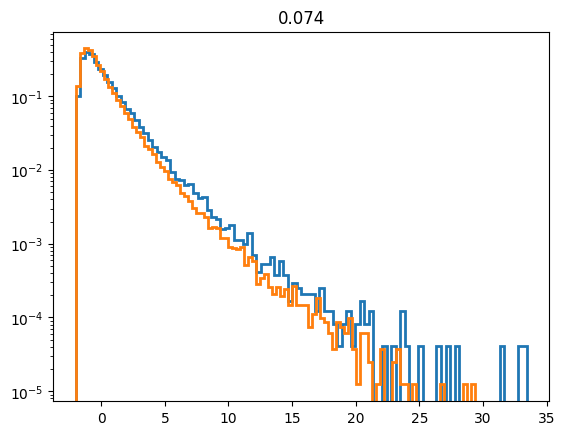

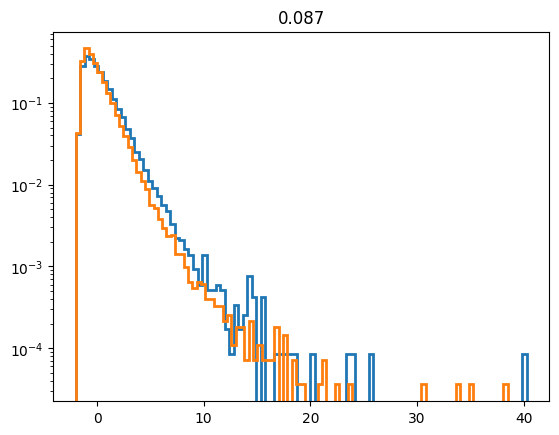

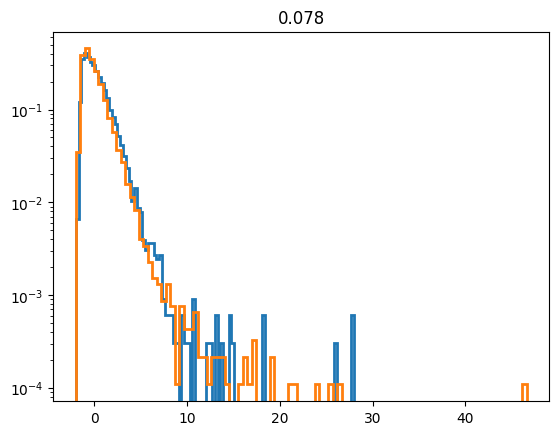

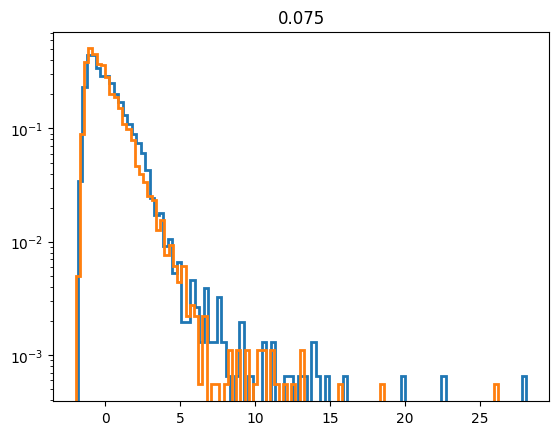

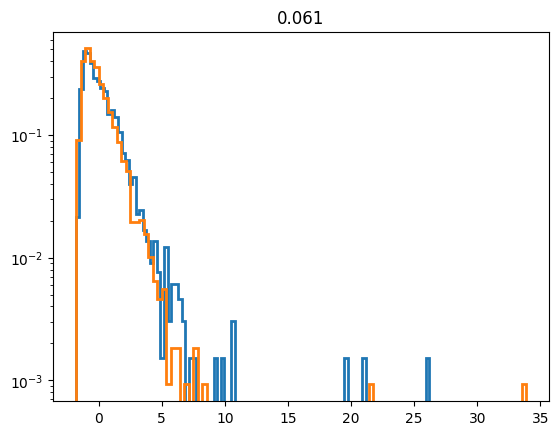

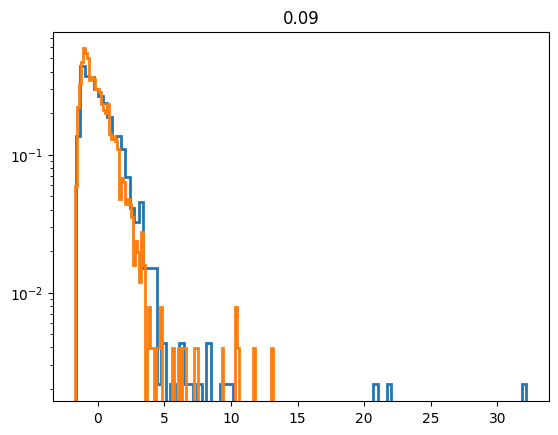

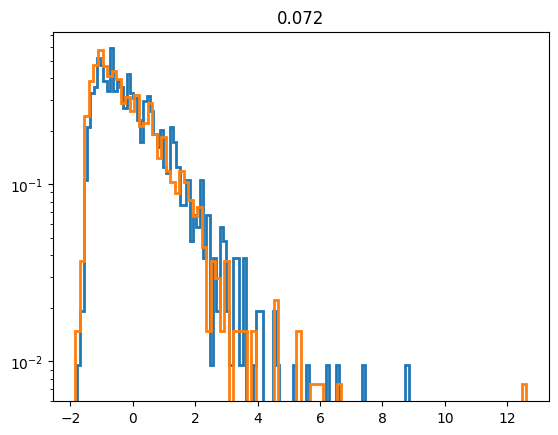

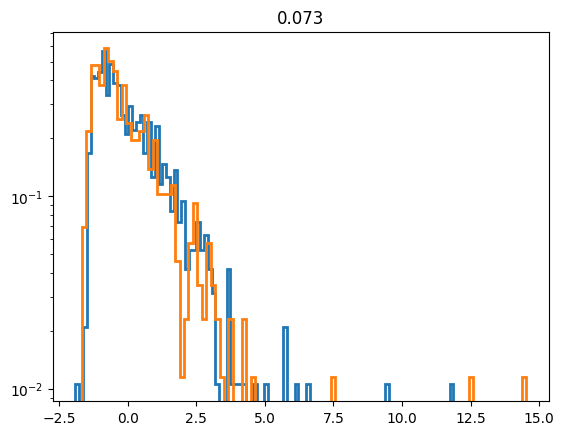

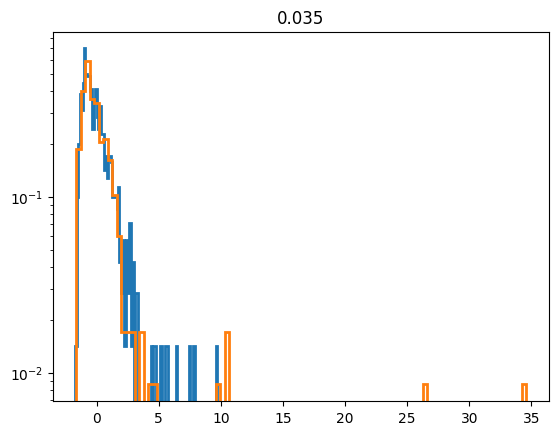

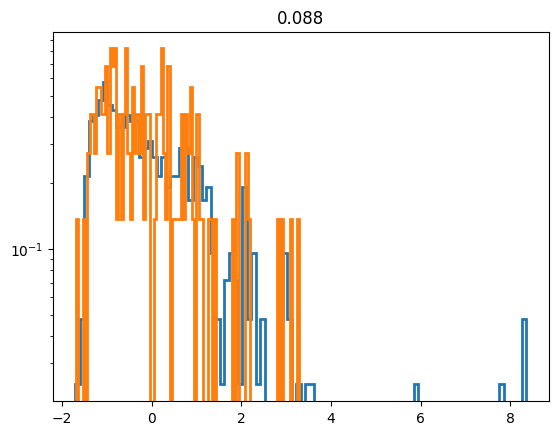

In [52]:
sep_var, p_val, bin_centers = get_statistic(angle_summCC, angle_summNC, energyCC, energyNC)
#sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              #fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

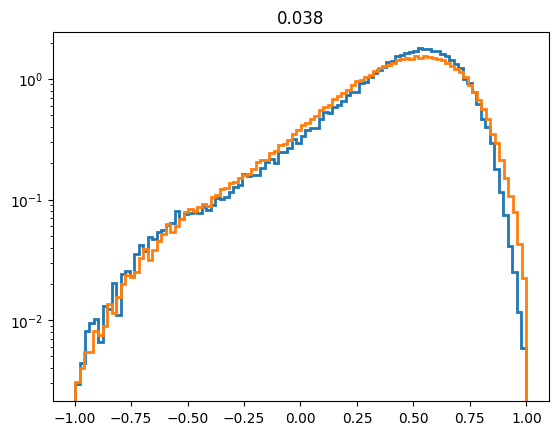

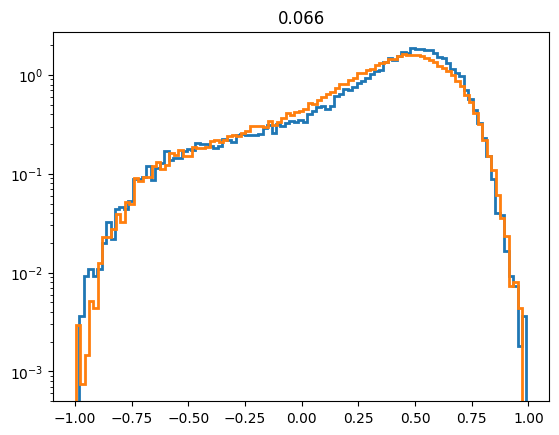

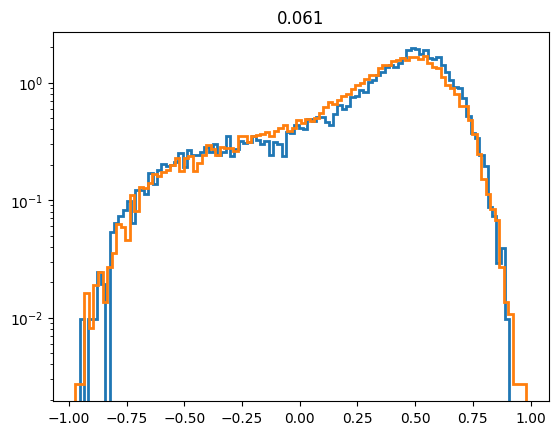

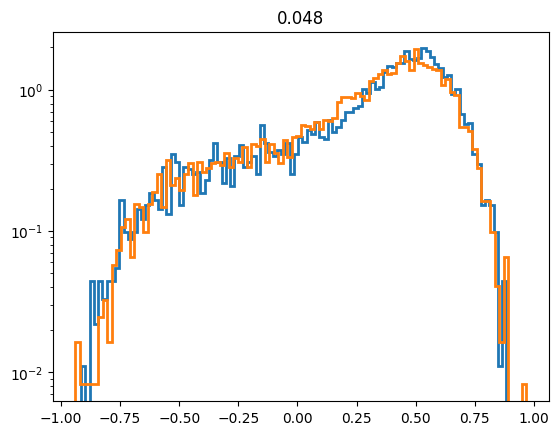

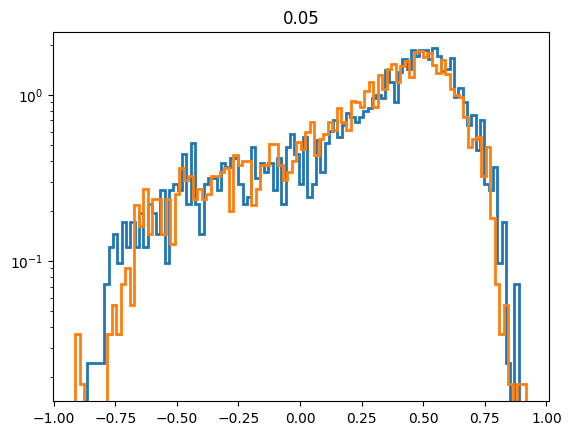

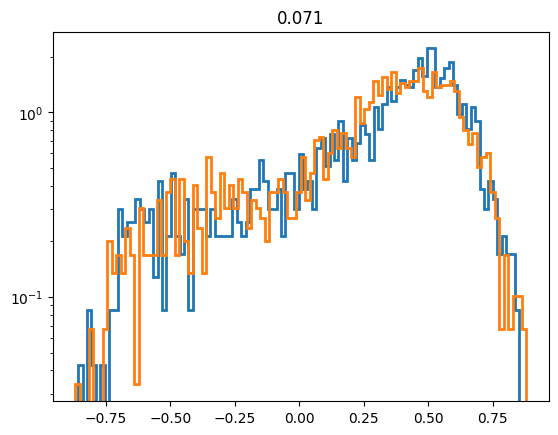

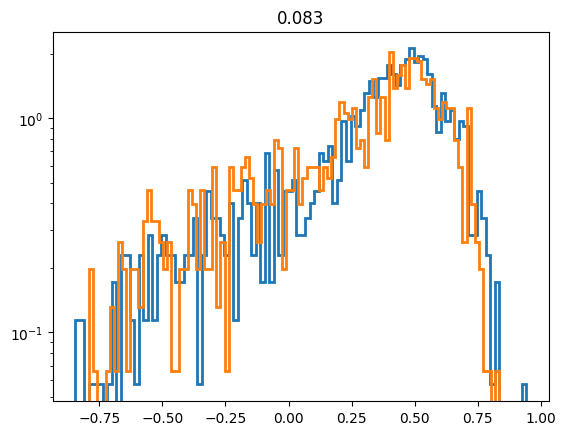

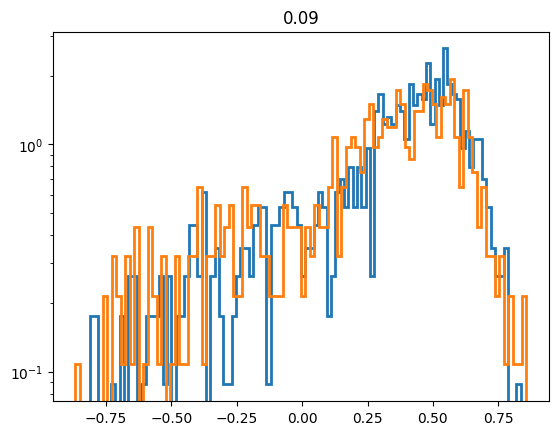

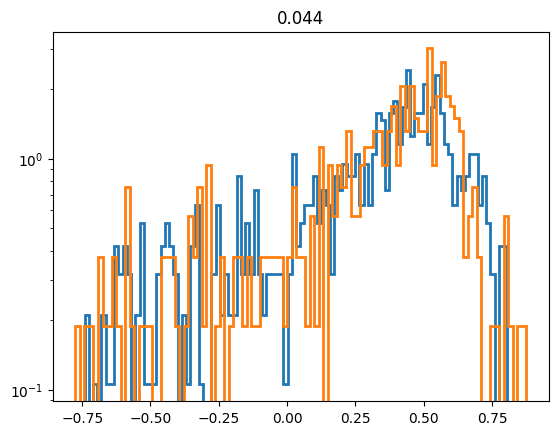

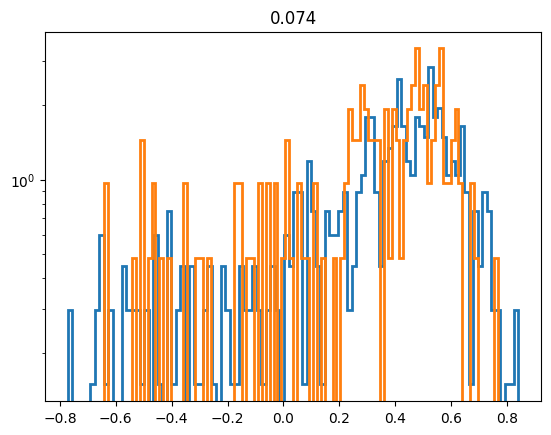

In [24]:
sep_var, p_val, bin_centers = get_statistic(angle_summCC, angle_summNC, energyCC, energyNC)
#sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              #fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

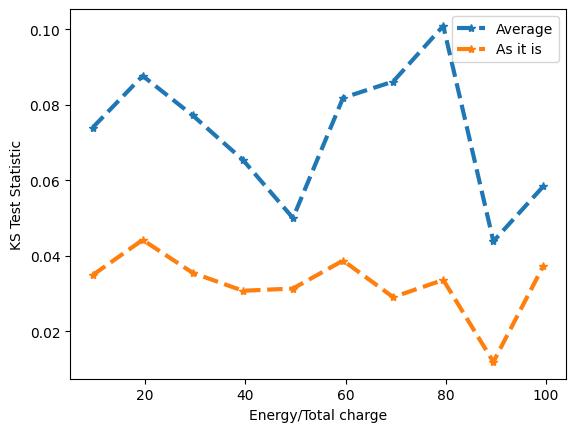

In [59]:
plt.plot(bin_centers, sep_var, '*--', linewidth=3, label='Average')
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

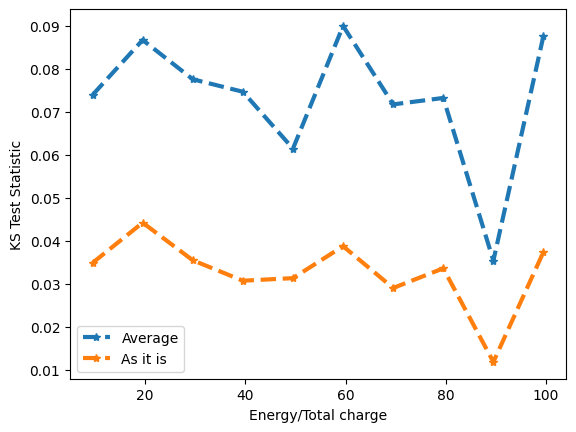

In [53]:
plt.plot(bin_centers, sep_var, '*--', linewidth=3, label='Average')
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

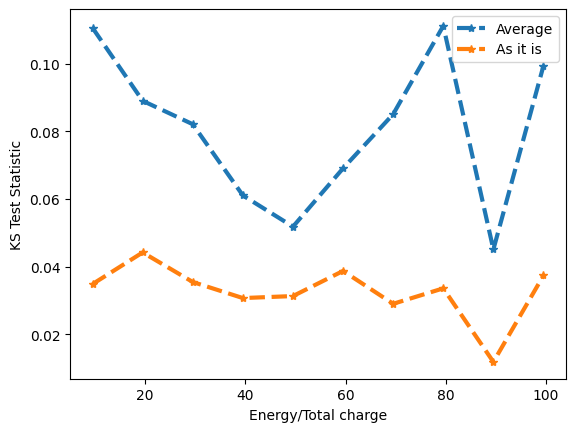

In [42]:
plt.plot(bin_centers, sep_var, '*--', linewidth=3, label='Average')
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

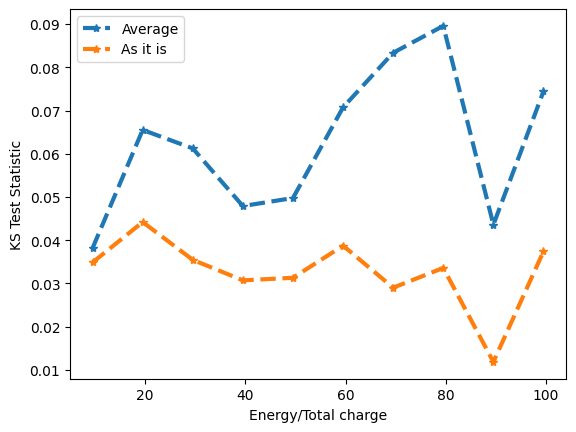

In [22]:
plt.plot(bin_centers, sep_var, '*--', linewidth=3, label='Average')
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

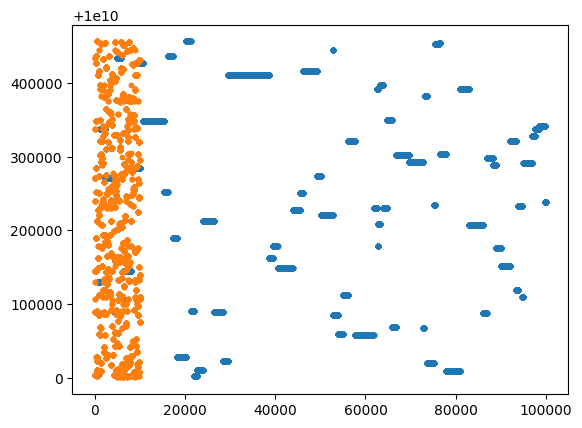

In [23]:
plt.plot(fCC.root.OMMapReco.col('om_counter')[0:100000], '.')
plt.plot(fCC.root.EventCounter.col('value')[0:10000], '.')

In [28]:
fCC.root.EventCounter

/EventCounter (Table(119591,)) ''
  description := {
  "Run": UInt32Col(shape=(), dflt=0, pos=0),
  "Event": UInt32Col(shape=(), dflt=0, pos=1),
  "SubEvent": UInt32Col(shape=(), dflt=0, pos=2),
  "SubEventStream": EnumCol(enum=Enum({'InIceSplit': 0}), dflt='InIceSplit', base=Int32Atom(shape=(), dflt=0), shape=(), pos=3),
  "exists": UInt8Col(shape=(), dflt=0, pos=4),
  "value": Float64Col(shape=(), dflt=0.0, pos=5)}
  byteorder := 'little'
  chunkshape := (2048,)